# Decision Trees: Two Worked Examples

Companion to the two mini examples: **Decision Trees: CEO Turnover**, a
classification tree, and **Regression Trees and Return Prediction**, a regression tree.

CART is a search over a finite list of candidate splits, and on five or six observations that list is short enough to print in full.

Each example runs twice:

1. **by hand** --- enumerate every candidate cutpoint, evaluate the CART cost function at
   each, and reproduce the tables on the slides;
2. **in `scikit-learn`** --- fit the same tree, draw it with `plot_tree`, and check that
   the fitted rules are the ones the hand calculation chose.

Both examples use the same cost function. For classification it weights Gini impurity,

$$J(k,t_k)=\frac{m_{\text{left}}}{m}\,G_{\text{left}}
+\frac{m_{\text{right}}}{m}\,G_{\text{right}},
\qquad G=1-\sum_{k=1}^{K}p_{k}^{2},$$

and for regression it weights node MSE,

$$J(k,t_k)=\frac{m_{\text{left}}}{m}\,\mathrm{MSE}_{\text{left}}
+\frac{m_{\text{right}}}{m}\,\mathrm{MSE}_{\text{right}},
\qquad \mathrm{MSE}_{\ell}=\frac{1}{N_{\ell}}\sum_{i\in\ell}(y_i-\bar y_{\ell})^{2}.$$

Only the impurity measure changes, so one function does both jobs.

Both data sets are typed into the notebook, so nothing needs to be downloaded and the
notebook runs unchanged in Colab.

## 1. Setup

Every feature and every return below is in percentage points, to maintain consistency wit the slides. 
CART is invariant to any increasing rescaling of a feature, but it makes
the thresholds `plot_tree` prints read directly against the slides.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import (DecisionTreeClassifier, DecisionTreeRegressor,
                          export_text, plot_tree)

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 710

BLUE = "#003865"
GREEN = "#64A70B"
GOLD = "#F2A900"
RED = "#DA291C"

## 2. The CART split search, written once

Three small functions carry both examples.

- `candidate_cutpoints` sorts a feature's distinct values and takes the midpoint between
  each neighbouring pair. With $m$ distinct values there are $m-1$ midpoints
- `gini` and `node_mse` are the two impurity measures.

`split_search` then does the only thing CART does at a node: try every
(feature, cutpoint) pair, and report the weighted impurity of the two children.

In [76]:
def candidate_cutpoints(values):
    """Midpoints between neighbouring distinct values: m distinct values give m - 1 cutpoints."""
    distinct = np.unique(values)                 # np.unique sorts as well as de-duplicates
    return (distinct[:-1] + distinct[1:]) / 2


def gini(labels):
    """Gini impurity of a node, 1 - sum_k p_k^2. Zero when every label in the node agrees."""
    labels = np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    shares = np.array([np.mean(labels == k) for k in np.unique(labels)])
    return float(1.0 - np.sum(shares ** 2))


def node_mse(values):
    """Node MSE around the node's own mean -- the best constant under squared-error loss."""
    values = np.asarray(values, dtype=float)
    if len(values) == 0:
        return 0.0
    return float(np.mean((values - values.mean()) ** 2))

In [77]:
def split_search(data, features, outcome, impurity, impurity_name="impurity", describe=None):
    """Evaluate the CART cost J(k, t_k) at every candidate split of `data`.

    Returns the parent node's impurity and one row per (feature, cutpoint) pair.
    `describe` is an optional labelling function used to print the child composition.
    """
    m = len(data)
    parent_impurity = impurity(data[outcome])

    rows = []
    for feature in features:
        for cutpoint in candidate_cutpoints(data[feature]):
            left = data.loc[data[feature] <= cutpoint, outcome]
            right = data.loc[data[feature] > cutpoint, outcome]
            impurity_left, impurity_right = impurity(left), impurity(right)

            # The CART cost: child impurities weighted by the share of the node each holds
            cost = (len(left) * impurity_left + len(right) * impurity_right) / m

            row = {"feature": feature, "cutpoint": cutpoint, "m_L": len(left)}
            if describe is not None:
                row["split_L"] = describe(left)
            row[f"{impurity_name}_L"] = impurity_left
            row["m_R"] = len(right)
            if describe is not None:
                row["split_R"] = describe(right)
            row[f"{impurity_name}_R"] = impurity_right
            row["J"] = cost
            row["improvement"] = parent_impurity - cost
            rows.append(row)

    return parent_impurity, pd.DataFrame(rows)


def one_feature(table, feature):
    """The rows of a split search belonging to one feature, indexed by cutpoint."""
    return (table.loc[table["feature"] == feature]
                 .drop(columns="feature")
                 .set_index("cutpoint")
                 .round(4))

`leaf_table` walks the tree from the root and records, for each leaf, the conditions collected along the way, the observations that land there, and the prediction. Those are the same quantities `plot_tree` prints inside each box, so the two views can be checked against one another, and against the slides.

In [78]:
def leaf_table(fitted, X, feature_names, member_labels):
    """One row per leaf: its root-to-leaf rule, the observations in it, and its prediction.

    `fitted.tree_` stores the fitted structure as parallel arrays. A node is a leaf when
    it has no left child, which scikit-learn marks with -1.
    """
    tree = fitted.tree_
    leaf_of_row = fitted.apply(X)                # which leaf each row of X falls into
    rules = {}

    def walk(node, conditions):
        if tree.children_left[node] == -1:
            rules[node] = " and ".join(conditions) if conditions else "(all observations)"
            return
        name = feature_names[tree.feature[node]]
        cutpoint = tree.threshold[node]
        walk(tree.children_left[node], conditions + [f"{name} <= {cutpoint:g}"])
        walk(tree.children_right[node], conditions + [f"{name} > {cutpoint:g}"])

    walk(0, [])

    rows = []
    for node, rule in rules.items():
        in_leaf = leaf_of_row == node
        rows.append({
            "fitted rule": rule,
            "members": ", ".join(np.asarray(member_labels)[in_leaf].astype(str)),
            "samples": int(in_leaf.sum()),
            "impurity": float(tree.impurity[node]),
            "prediction": fitted.predict(X[in_leaf])[0],
        })
    return pd.DataFrame(rows)

## 3. Decision Trees: CEO Turnover

Five CEOs, two features observed at the end of the year, and a binary outcome. The board
either retained the CEO or fired them.

The data are the slides' *Decision Trees: CEO Turnover* frame, which in turn comes from
`Topic 3 - Decision trees.xlsx` on Canvas.

In [79]:
ceo = pd.DataFrame({
    "ceo_id":       [1, 2, 3, 4, 5],
    "SalesGR":      [-5.0, 10.0, 2.0, 12.0, 5.0],      # sales growth over the year, %
    "ROE":          [-8.0, 15.0, 10.0, 7.0, -10.0],    # return on equity, %
    "status":       ["Fired", "Retain", "Retain", "Retain", "Fired"],
}).set_index("ceo_id")

CEO_FEATURES = ["SalesGR", "ROE"]

candidates_per_feature = {f: len(candidate_cutpoints(ceo[f])) for f in CEO_FEATURES}
n_fired = int((ceo["status"] == "Fired").sum())

print(f"CEOs                   : {len(ceo)}")
print(f"Fired / retained       : {n_fired} / {len(ceo) - n_fired}")
print(f"Cutpoints per feature  : {candidates_per_feature}")
print(f"Candidate first splits : {sum(candidates_per_feature.values())}")
ceo

CEOs                   : 5
Fired / retained       : 2 / 3
Cutpoints per feature  : {'SalesGR': 4, 'ROE': 4}
Candidate first splits : 8


,SalesGR,ROE,status
ceo_id,,,
1,-5.0,-8.0,Fired
2,10.0,15.0,Retain
3,2.0,10.0,Retain
4,12.0,7.0,Retain
5,5.0,-10.0,Fired


Two features and four cutpoints each give 8 possible choices for the first split.

Before searching, the root node's own impurity. Two of the five were fired, so

$$G_{\text{root}} = 1 - 0.4^{2} - 0.6^{2} = 0.48 .$$

Any split has to beat that number to be worth making.

In [80]:
def fired_retain(labels):
    """Compose a node as 'fired / retained'."""
    labels = np.asarray(labels)
    return f"{int((labels == 'Fired').sum())} / {int((labels == 'Retain').sum())}"


root_gini, ceo_splits = split_search(
    ceo, CEO_FEATURES, outcome="status",
    impurity=gini, impurity_name="gini", describe=fired_retain,
)

print(f"Root Gini impurity, by hand   : 1 - 0.4**2 - 0.6**2 = {1 - 0.4 ** 2 - 0.6 ** 2:.4f}")
print(f"Root Gini impurity, from gini(): {root_gini:.4f}")

Root Gini impurity, by hand   : 1 - 0.4**2 - 0.6**2 = 0.4800
Root Gini impurity, from gini(): 0.4800


### 3.1 The sales-growth feature

Sort on sales growth, take the midpoints, and evaluate the CART cost at each. This
reproduces the *The Sales-Growth Feature* table.

In [81]:
one_feature(ceo_splits, "SalesGR")

,m_L,split_L,gini_L,m_R,split_R,gini_R,J,improvement
cutpoint,,,,,,,,
-1.5,1,1 / 0,0.0000,4,1 / 3,0.3750,0.3000,0.1800
3.5,2,1 / 1,0.5000,3,1 / 2,0.4444,0.4667,0.0133
7.5,3,2 / 1,0.4444,2,0 / 2,0.0000,0.2667,0.2133
11.0,4,2 / 2,0.5000,1,0 / 1,0.0000,0.4000,0.0800


The lowest cost is $0.2667$ at a cutpoint of $7.5\%$: if SalesGR $>7.5\%$ predict
*Retain*, otherwise *Fired*. It is an improvement on the root's $0.48$, but the left
branch is still mixed --- two fired and one retained, Gini $0.4444$ --- so the tree would
have to keep splitting.

### 3.2 The return-on-equity feature

Now the same search on ROE.

In [82]:
one_feature(ceo_splits, "ROE")

,m_L,split_L,gini_L,m_R,split_R,gini_R,J,improvement
cutpoint,,,,,,,,
-9.0,1,1 / 0,0.0000,4,1 / 3,0.375,0.3000,0.1800
-0.5,2,2 / 0,0.0000,3,0 / 3,0.000,0.0000,0.4800
8.5,3,2 / 1,0.4444,2,0 / 2,0.000,0.2667,0.2133
12.5,4,2 / 2,0.5000,1,0 / 1,0.000,0.4000,0.0800


A cost of exactly **zero** at a cutpoint of $-0.5\%$. Both children are pure: the two CEOs
with negative ROE were fired, the three with positive ROE were retained. Nothing can beat
a cost of zero, so CART takes this split and stops --- there is no impurity left to remove.

In [83]:
best_ceo_split = ceo_splits.loc[ceo_splits["J"].idxmin()]

print("Winner across all 8 candidates")
print(f"  feature   : {best_ceo_split['feature']}")
print(f"  cutpoint  : {best_ceo_split['cutpoint']:.1f}%")
print(f"  CART cost : {best_ceo_split['J']:.4f}   (root was {root_gini:.4f})")
print()
print("All 8 candidates, cheapest first")
ceo_splits.sort_values("J")[["feature", "cutpoint", "J", "improvement"]].round(4)

Winner across all 8 candidates
  feature   : ROE
  cutpoint  : -0.5%
  CART cost : 0.0000   (root was 0.4800)

All 8 candidates, cheapest first


,feature,cutpoint,J,improvement
5,ROE,-0.5,0.0000,0.4800
2,SalesGR,7.5,0.2667,0.2133
6,ROE,8.5,0.2667,0.2133
0,SalesGR,-1.5,0.3000,0.1800
4,ROE,-9.0,0.3000,0.1800
3,SalesGR,11.0,0.4000,0.0800
7,ROE,12.5,0.4000,0.0800
1,SalesGR,3.5,0.4667,0.0133


### 3.3 The same tree from `scikit-learn`

`DecisionTreeClassifier` runs exactly the search above. Its defaults are the ones the
slides assume: `criterion="gini"`, and no depth or leaf-size restriction, which does not
bind here because the tree reaches purity after one split.

In [84]:
ceo_tree = DecisionTreeClassifier(criterion="gini", random_state=SEED)
ceo_tree.fit(ceo[CEO_FEATURES], ceo["status"])

print(export_text(ceo_tree, feature_names=CEO_FEATURES))
print(f"depth  : {ceo_tree.get_depth()}")
print(f"leaves : {ceo_tree.get_n_leaves()}")

|--- ROE <= -0.50
|   |--- class: Fired
|--- ROE >  -0.50
|   |--- class: Retain

depth  : 1
leaves : 2


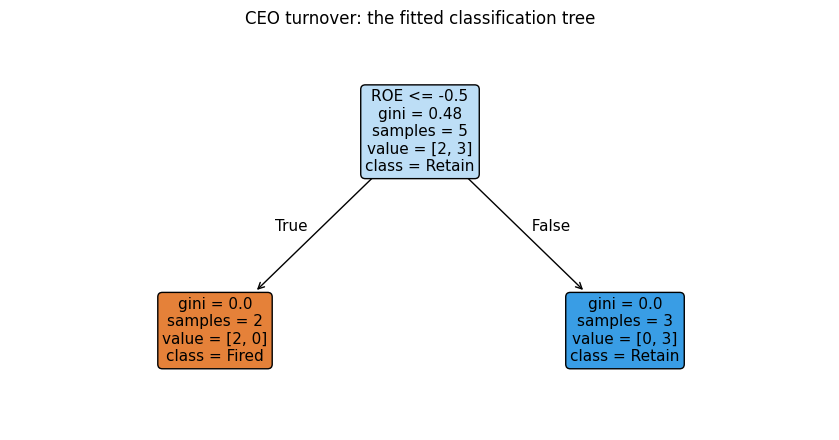

In [85]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
plot_tree(
    ceo_tree,
    feature_names=CEO_FEATURES,
    class_names=list(ceo_tree.classes_),
    filled=True, rounded=True, impurity=True, fontsize=11, ax=ax,
)
ax.set_title("CEO turnover: the fitted classification tree", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Regression Trees and Return Prediction

Six stocks observed at the end of month $t$, with momentum and volatility known at that
date and the excess return realised over month $t+1$. The timing is the same convention
used throughout the course: features are dated $t$, the target is dated $t+1$, and nothing
known only at $t+1$ is allowed into the feature set.

Returns are in percent, so the MSE below is in percent-squared.

In [86]:
stock_month = pd.DataFrame({
    "stock":      ["A", "B", "C", "D", "E", "F"],
    "momentum":   [-8.0, -4.0, 4.0, 12.0, 6.0, 10.0],       # known at end of month t, %
    "volatility": [4.0, 7.0, 5.0, 6.0, 10.0, 15.0],         # known at end of month t, %
    "ret_next":   [-0.30, -0.10, 0.50, 0.40, 0.10, 0.00],   # realised over month t+1, %
}).set_index("stock")

RETURN_FEATURES = ["momentum", "volatility"]
TARGET = "ret_next"

candidates_per_feature = {f: len(candidate_cutpoints(stock_month[f])) for f in RETURN_FEATURES}

print(f"Stocks                : {len(stock_month)}")
print(f"Cutpoints per feature : {candidates_per_feature}")
print(f"Candidate first splits: {sum(candidates_per_feature.values())}")
print(f"Root mean forecast    : {stock_month[TARGET].mean():+.2f}%")
print(f"Root MSE              : {node_mse(stock_month[TARGET]):.4f}")
stock_month

Stocks                : 6
Cutpoints per feature : {'momentum': 5, 'volatility': 5}
Candidate first splits: 10
Root mean forecast    : +0.10%
Root MSE              : 0.0767


,momentum,volatility,ret_next
stock,,,
A,-8.0,4.0,-0.3
B,-4.0,7.0,-0.1
C,4.0,5.0,0.5
D,12.0,6.0,0.4
E,6.0,10.0,0.1
F,10.0,15.0,0.0


Momentum/volatility has six distinct values and so contributes five cutpoints.

**The root forecast.** With no split at all, the best constant under squared-error loss is
the sample mean, $+0.10\%$, and the MSE around it is $0.0767$. Every split below is judged
against that number.

### 4.1 The first split

All ten candidates, momentum and volatility together.

In [87]:
root_mse, return_splits = split_search(
    stock_month, RETURN_FEATURES, outcome=TARGET,
    impurity=node_mse, impurity_name="mse",
)

print(f"Root MSE: {root_mse:.4f}\n")
return_splits.set_index(["feature", "cutpoint"]).round(4)

Root MSE: 0.0767



m_L   mse_L  m_R   mse_R       J  improvement
feature    cutpoint                                               
momentum   -6.0        1  0.0000    5  0.0536  0.0447       0.0320
            0.0        2  0.0100    4  0.0425  0.0317       0.0450
            5.0        3  0.1156    3  0.0289  0.0722       0.0044
            8.0        4  0.0875    2  0.0400  0.0717       0.0050
            11.0       5  0.0704    1  0.0000  0.0587       0.0180
volatility  4.5        1  0.0000    5  0.0536  0.0447       0.0320
            5.5        2  0.1600    4  0.0350  0.0767       0.0000
            6.5        3  0.1267    3  0.0067  0.0667       0.0100
            8.5        4  0.1119    2  0.0025  0.0754       0.0013
            12.5       5  0.0896    1  0.0000  0.0747       0.0020

Momentum $\leq 0$ is the winner at $J = 0.0317$, an improvement of $0.0450$ on the root.
It sends A and B left, where the forecast becomes $-0.20\%$, and C, D, E and F right,
where the forecast becomes $+0.25\%$.

The best volatility cutpoint reaches only $0.0447$.

In [88]:
best_first = return_splits.loc[return_splits["J"].idxmin()]
best_volatility = return_splits.loc[
    return_splits.loc[return_splits["feature"] == "volatility", "J"].idxmin()]

print(f"Best overall   : {best_first['feature']} <= {best_first['cutpoint']:g}   "
      f"J = {best_first['J']:.4f}")
print(f"Best volatility: {best_volatility['feature']} <= {best_volatility['cutpoint']:g}   "
      f"J = {best_volatility['J']:.4f}")

left_child = stock_month.loc[stock_month["momentum"] <= best_first["cutpoint"]]
right_child = stock_month.loc[stock_month["momentum"] > best_first["cutpoint"]]

for name, child in [("left  (momentum <= 0)", left_child), ("right (momentum >  0)", right_child)]:
    print(f"\n{name}: {list(child.index)}")
    print(f"  forecast {child[TARGET].mean():+.2f}%   MSE {node_mse(child[TARGET]):.4f}   "
          f"range {child[TARGET].min():+.2f}% to {child[TARGET].max():+.2f}%")

Best overall   : momentum <= 0   J = 0.0317
Best volatility: volatility <= 4.5   J = 0.0447

left  (momentum <= 0): ['A', 'B']
  forecast -0.20%   MSE 0.0100   range -0.30% to -0.10%

right (momentum >  0): ['C', 'D', 'E', 'F']
  forecast +0.25%   MSE 0.0425   range +0.00% to +0.50%


### 4.2 The second split, inside the right child

The right child $\{C, D, E, F\}$ has a node MSE of $0.0425$ and still spans
$0.00\%$ to $+0.50\%$.

In [89]:
right_mse, right_splits = split_search(
    right_child, RETURN_FEATURES, outcome=TARGET,
    impurity=node_mse, impurity_name="mse",
)

best_right_momentum = right_splits.loc[
    right_splits.loc[right_splits["feature"] == "momentum", "J"].idxmin()]

print(f"Right child {list(right_child.index)}, node MSE {right_mse:.4f}\n")
print(f"Best momentum cutpoint here: momentum <= {best_right_momentum['cutpoint']:g}, "
      f"J = {best_right_momentum['J']:.4f}\n")
right_splits.set_index(["feature", "cutpoint"]).round(4)

Right child ['C', 'D', 'E', 'F'], node MSE 0.0425

Best momentum cutpoint here: momentum <= 5, J = 0.0217



m_L   mse_L  m_R   mse_R       J  improvement
feature    cutpoint                                               
momentum   5.0         1  0.0000    3  0.0289  0.0217       0.0208
           8.0         2  0.0400    2  0.0400  0.0400       0.0025
           11.0        3  0.0467    1  0.0000  0.0350       0.0075
volatility 5.5         1  0.0000    3  0.0289  0.0217       0.0208
           8.0         2  0.0025    2  0.0025  0.0025       0.0400
           12.5        3  0.0289    1  0.0000  0.0217       0.0208

Volatility predicts returns conditional on positive momentum.

### 4.3 Fitting the tree, and choosing where to stop

Left alone, `DecisionTreeRegressor` grows until every leaf is
pure, and with six distinct returns "pure" means six leaves of one stock each, with an MSE
of exactly zero, and a forecast for each stock equal to its own realised return.

The three-leaf tree on the slides therefore needs a stopping rule. `min_samples_leaf=2`
says a leaf must average at least two stocks.


In [90]:
# The slides' tree: a leaf must hold at least two stocks
return_tree = DecisionTreeRegressor(
    criterion="squared_error", min_samples_leaf=2, random_state=SEED)
return_tree.fit(stock_month[RETURN_FEATURES], stock_month[TARGET])

# The same estimator with nothing holding it back
unconstrained_tree = DecisionTreeRegressor(
    criterion="squared_error", random_state=SEED)
unconstrained_tree.fit(stock_month[RETURN_FEATURES], stock_month[TARGET])

for name, fitted in [("min_samples_leaf=2", return_tree), ("defaults", unconstrained_tree)]:
    in_sample = fitted.predict(stock_month[RETURN_FEATURES])
    print(f"{name:<20} depth {fitted.get_depth()}   leaves {fitted.get_n_leaves()}   "
          f"training MSE {np.mean((stock_month[TARGET] - in_sample) ** 2):.4f}")

min_samples_leaf=2   depth 2   leaves 3   training MSE 0.0050
defaults             depth 3   leaves 6   training MSE 0.0000


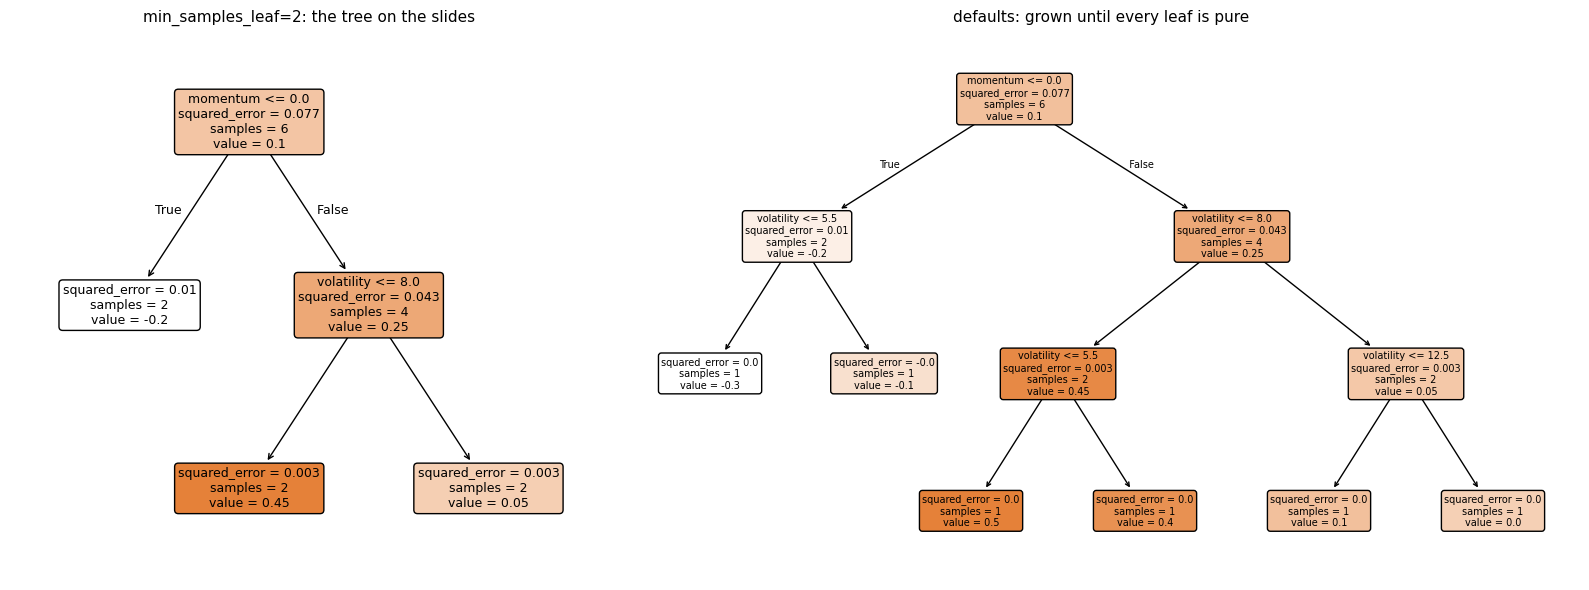

In [91]:
# The unconstrained tree needs more room: twice the leaves and one level deeper
fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 1.6]})

for ax, fitted, size, title in [
    (axes[0], return_tree, 9, "min_samples_leaf=2: the tree on the slides"),
    (axes[1], unconstrained_tree, 7, "defaults: grown until every leaf is pure"),
]:
    plot_tree(fitted, feature_names=RETURN_FEATURES, filled=True, rounded=True,
              impurity=True, precision=3, fontsize=size, ax=ax)
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()

### 4.5 The partition

A tree is a partition of the feature space. Two splits cut the momentum-volatility plane
into three rectangles, and every stock inside a rectangle receives the identical forecast.

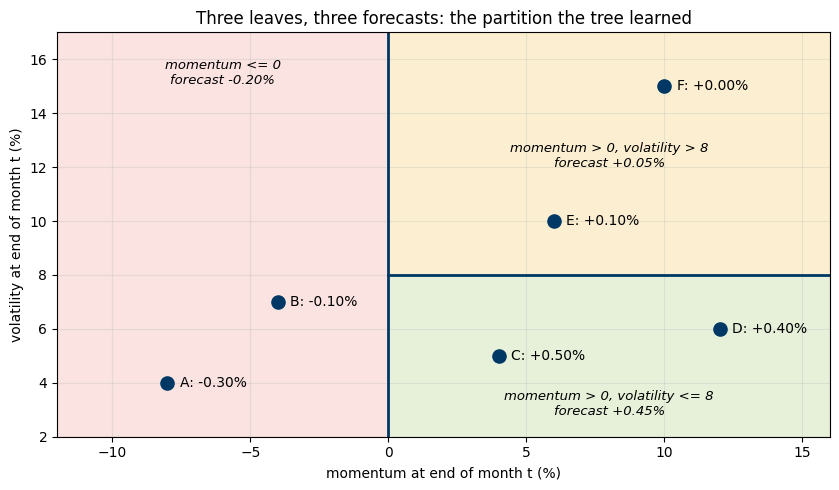

In [92]:
mom_lo, mom_hi = -12.0, 16.0
vol_lo, vol_hi = 2.0, 17.0

fig, ax = plt.subplots(figsize=(8.5, 5))

# One rectangle per leaf, shaded by the sign and size of its forecast
ax.fill_betweenx([vol_lo, vol_hi], mom_lo, 0, color=RED, alpha=0.13)
ax.fill_between([0, mom_hi], vol_lo, 8, color=GREEN, alpha=0.15)
ax.fill_between([0, mom_hi], 8, vol_hi, color=GOLD, alpha=0.18)

# The two fitted split boundaries
ax.axvline(0, color=BLUE, lw=2)
ax.plot([0, mom_hi], [8, 8], color=BLUE, lw=2)

for label, (_, row) in zip(stock_month.index, stock_month.iterrows()):
    ax.scatter(row["momentum"], row["volatility"], s=90, color=BLUE, zorder=3)
    ax.annotate(f"{label}: {row[TARGET]:+.2f}%",
                (row["momentum"], row["volatility"]),
                textcoords="offset points", xytext=(9, -3), fontsize=10)

leaf_labels = [(-6.0, 15.5, "momentum <= 0\nforecast -0.20%"),
               (8.0, 3.2, "momentum > 0, volatility <= 8\nforecast +0.45%"),
               (8.0, 12.4, "momentum > 0, volatility > 8\nforecast +0.05%")]
for x, y, text in leaf_labels:
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5, style="italic")

ax.set_xlim(mom_lo, mom_hi)
ax.set_ylim(vol_lo, vol_hi)
ax.set_xlabel("momentum at end of month t (%)")
ax.set_ylabel("volatility at end of month t (%)")
ax.set_title("Three leaves, three forecasts: the partition the tree learned")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()